# Notebook 5 — CNN Model
**Նպատակ:** 1D Convolutional Neural Network-ով գնի ուղղության կանխատեսում  
**Ենթահարց 6:** CNN-ի արդյունավետության գնահատում LSTM-ի համեմատ

## 1. Libraries & Load Data

In [2]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization, Input,
    Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings, os
warnings.filterwarnings('ignore')
os.chdir('/Users/lusine/Desktop')
plt.style.use('seaborn-v0_8-darkgrid')

with open('data/features/model_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train_seq']
X_val   = data['X_val_seq']
X_test  = data['X_test_seq']
y_train = data['y_train_seq']
y_val   = data['y_val_seq']
y_test  = data['y_test_seq']
N_FEATURES = data['n_features']
SEQ_LEN    = data['SEQUENCE_LEN']

y_train_k = y_train + 1
y_val_k   = y_val   + 1
y_test_k  = y_test  + 1

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')

X_train: (9984, 30, 44)
X_test:  (2116, 30, 44)


## 2. CNN Architecture
1D CNN — local pattern-ների հայտնաբերում ժամանակային շարքում։

In [3]:
def build_cnn(seq_len, n_features, n_classes=3):
    model = Sequential([
        Input(shape=(seq_len, n_features)),

        # Block 1
        Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Block 2
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.25),

        # Block 3
        Conv1D(256, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        GlobalAveragePooling1D(),
        Dropout(0.3),

        # Dense head
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(SEQ_LEN, N_FEATURES)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 15, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 15, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 7, 256)         │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,315 (927.01 KB)

 Trainable params: 236,035 (922.01 KB)

 Non-trainable params: 1,280 (5.00 KB)

## 3. Training

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('models/cnn_best.keras', save_best_only=True, monitor='val_loss')
]

history = cnn_model.fit(
    X_train, y_train_k,
    validation_data=(X_val, y_val_k),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3982 - loss: 1.1212 - val_accuracy: 0.3710 - val_loss: 1.0874 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4127 - loss: 1.0847 - val_accuracy: 0.4074 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4316 - loss: 1.0743 - val_accuracy: 0.3946 - val_loss: 1.0843 - learning_rate: 0.0010
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4334 - loss: 1.0653 - val_accuracy: 0.4026 - val_loss: 1.0868 - learning_rate: 0.0010
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4431 - loss: 1.0581 - val_accuracy: 0.4031 - val_loss: 1.0904 - learning_rate: 0.0010
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4547 - loss: 1.0516 - val_accuracy: 0.3889 - val_loss: 1.0859 - learning_rate: 0.0010
Epoch 7/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4602 - l

## 4. Training History

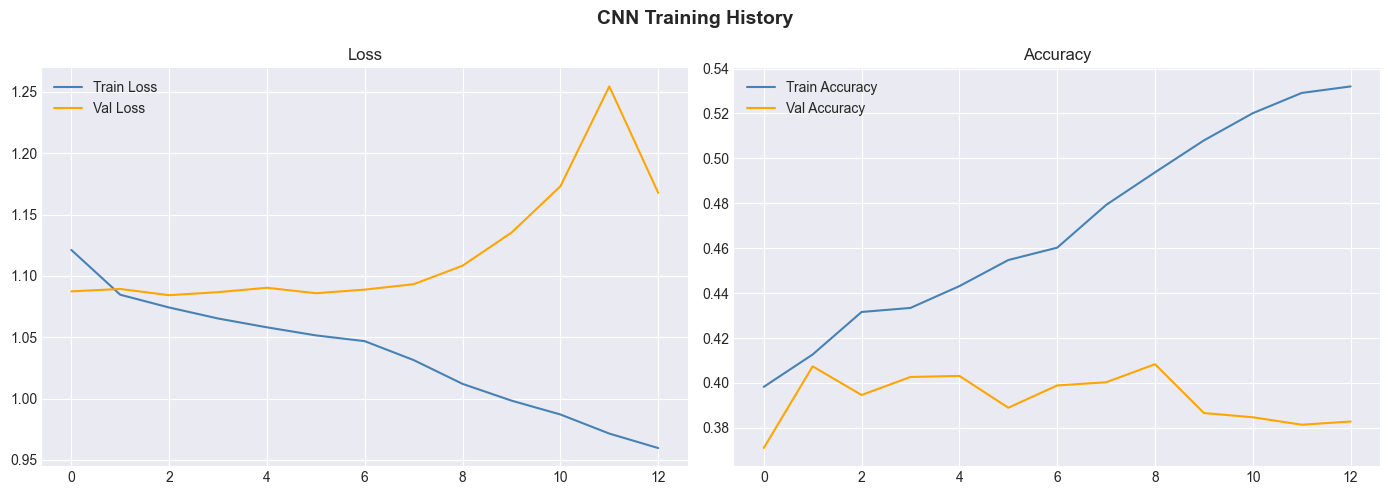

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/cnn_training_history.png', dpi=150)
plt.show()

## 5. Evaluation

In [6]:
y_pred_prob = cnn_model.predict(X_test)
y_pred      = np.argmax(y_pred_prob, axis=1) - 1

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print('=== CNN Test Results ===')
print(f'Accuracy:  {acc:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(classification_report(y_test, y_pred, target_names=['Down(-1)', 'Neutral(0)', 'Up(1)']))

cnn_results = {
    'model': 'CNN',
    'accuracy':  acc,
    'f1':        f1,
    'precision': prec,
    'recall':    rec,
    'y_pred':    y_pred,
    'y_pred_prob': y_pred_prob,
    'history':   history.history
}
with open('results/cnn_results.pkl', 'wb') as f:
    pickle.dump(cnn_results, f)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== CNN Test Results ===
Accuracy:  0.3941
F1 Score:  0.3910
Precision: 0.3947
Recall:    0.3941
              precision    recall  f1-score   support

    Down(-1)       0.38      0.44      0.41       787
  Neutral(0)       0.39      0.27      0.32       490
       Up(1)       0.42      0.42      0.42       839

    accuracy                           0.39      2116
   macro avg       0.39      0.38      0.38      2116
weighted avg       0.39      0.39      0.39      2116



## 6. Confusion Matrix & Visualizations

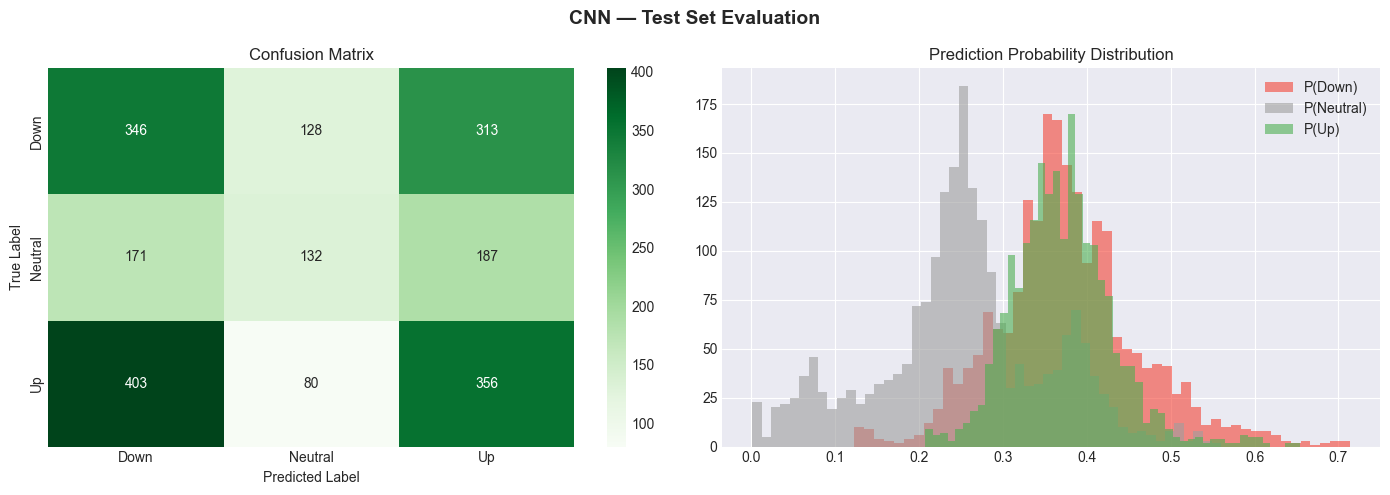

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN — Test Set Evaluation', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Down', 'Neutral', 'Up'],
            yticklabels=['Down', 'Neutral', 'Up'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

axes[1].hist(y_pred_prob[:, 0], bins=50, alpha=0.6, label='P(Down)',    color='#F44336')
axes[1].hist(y_pred_prob[:, 1], bins=50, alpha=0.6, label='P(Neutral)', color='#9E9E9E')
axes[1].hist(y_pred_prob[:, 2], bins=50, alpha=0.6, label='P(Up)',      color='#4CAF50')
axes[1].set_title('Prediction Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/cnn_evaluation.png', dpi=150)
plt.show()

## 7. Feature Group Ablation Study

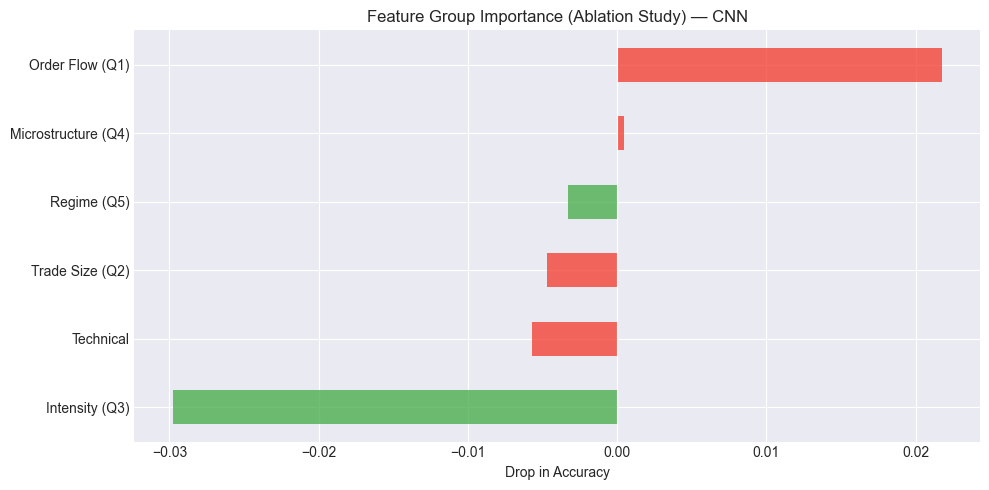

In [8]:
FEATURE_GROUPS = {
    'Order Flow (Q1)':      list(range(0, 10)),
    'Trade Size (Q2)':      list(range(10, 18)),
    'Intensity (Q3)':       list(range(18, 28)),
    'Microstructure (Q4)':  list(range(28, 34)),
    'Regime (Q5)':          list(range(34, 39)),
    'Technical':            list(range(39, 44)),
}

group_importance = {}
for group_name, indices in FEATURE_GROUPS.items():
    X_abl = X_test.copy()
    X_abl[:, :, indices] = 0
    y_pred_abl = np.argmax(cnn_model.predict(X_abl, verbose=0), axis=1) - 1
    group_importance[group_name] = acc - accuracy_score(y_test, y_pred_abl)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4CAF50' if v > 0 else '#F44336' for v in group_importance.values()]
pd.Series(group_importance).sort_values().plot(kind='barh', ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('Feature Group Importance (Ablation Study) — CNN', fontsize=12)
ax.set_xlabel('Drop in Accuracy')
plt.tight_layout()
plt.savefig('results/cnn_feature_importance.png', dpi=150)
plt.show()

**Հաջորդ → Notebook 6: Transformer Model**